In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import becquerel as bq


In [97]:
# Tiempo (min)
tiempo = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17])
tiempo_tapasup = np.array([0, 1, 2, 3, 4, 5])
tiempo_tapainf = np.array([0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11])

# Cuentas por segundo en el pico de 511 keV
cuentas = np.array([95.53, 90.95, 80.87, 78.27, 69.52, 65.60, 1.45, 2.07, 1.98, 1.42, 1.53, 1.07, 0.47, 0.85, 0.67, 0.72, 0.9])
cuentas_tapasup = np.array([95.53, 90.95, 80.87, 78.27, 69.52, 65.60])
cuentas_tapainf = np.array([1.45, 2.07, 1.98, 1.42, 1.53, 1.07, 0.47, 0.85, 0.67, 0.72, 0.9])

In [98]:
# Tiempo (min)
tiempo = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17])
tiempo_tapasup = np.array([0, 1, 2, 3, 4, 5])
tiempo_tapainf = np.array([0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11])

# Cuentas por segundo en el pico de 511 keV
cuentas_tapasup = np.array([94.23, 90.37, 82.47, 78.27, 70.95, 65.10])
cuentas_tapainf = np.array([1.68, 2.35, 2.03, 1.42, 1.27, 1.07, 0.42, 0.95, 1.02, 0.72, 0.98])

#Para calcular el error uso que cuentasporseg = areadelpico / tiempo entonces: errorCuentasporseg = errorareadelpico/tiempo
cuentastapasup_error = np.array([1.42, 1.33, 1.26, 1.26, 1.18, 1.16])
cuentastapainf_error = np.array([0.26, 0.31, 0.25, 0.28, 0.26, 0.26, 0.2, 0.26, 0.21, 0.2, 0.25])


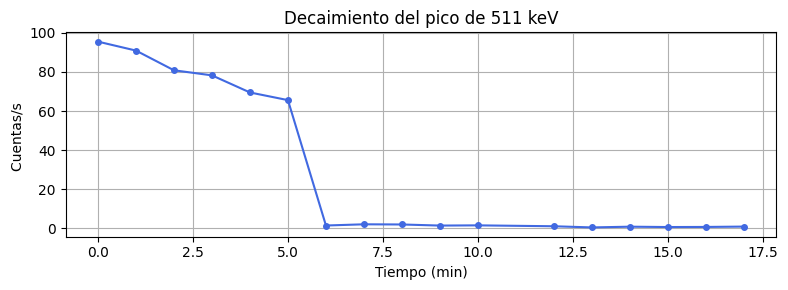

In [99]:
plt.figure(figsize=(8,3))
plt.plot(tiempo, cuentas, 'o-', color='royalblue', markersize=4)

plt.xlabel('Tiempo (min)')
plt.ylabel('Cuentas/s ')
plt.title('Decaimiento del pico de 511 keV')
plt.grid(True)

plt.tight_layout()
plt.show()

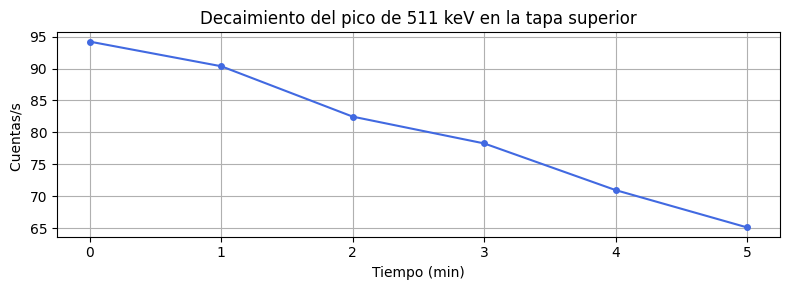

In [100]:
plt.figure(figsize=(8,3))
plt.plot(tiempo_tapasup, cuentas_tapasup, 'o-', color='royalblue', markersize=4)

plt.xlabel('Tiempo (min)')
plt.ylabel('Cuentas/s ')
plt.title('Decaimiento del pico de 511 keV en la tapa superior')
plt.grid(True)

plt.tight_layout()
plt.show()

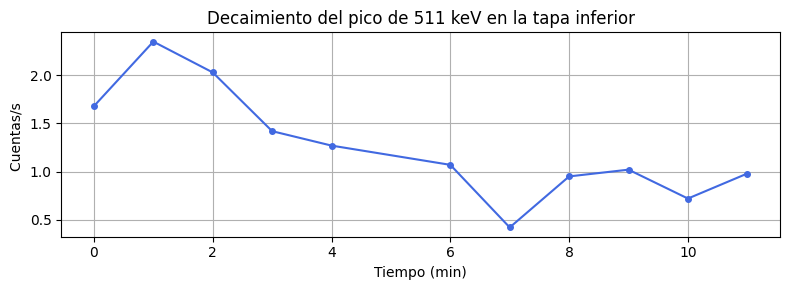

In [101]:
plt.figure(figsize=(8,3))
plt.plot(tiempo_tapainf, cuentas_tapainf, 'o-', color='royalblue', markersize=4)

plt.xlabel('Tiempo (min)')
plt.ylabel('Cuentas/s ')
plt.title('Decaimiento del pico de 511 keV en la tapa inferior')
plt.grid(True)

plt.tight_layout()
plt.show()

In [102]:
# Modelo exponencial
def exponencial(t, N0, lam):
    return N0 * np.exp(-lam * t)

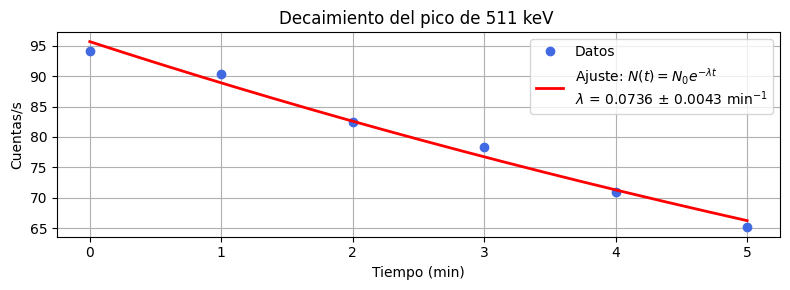

N0 = 95.70 ± 1.09
λ  = 0.073650 ± 0.004280 min^-1
Vida media = 9.41 ± 0.55 min


In [103]:
# Ajuste
popt, pcov = curve_fit(exponencial, tiempo_tapasup, cuentas_tapasup,
                       p0=[cuentas[0], 0.01])

N0_tapasup, lam_tapasup = popt
err_N0_tapasup, err_lam_tapasup = np.sqrt(np.diag(pcov))

# Curva ajustada
t_fit_tapasup = np.linspace(tiempo_tapasup.min(), tiempo_tapasup.max(), 300)
cuentas_fit_tapasup = exponencial(t_fit_tapasup, N0_tapasup, lam_tapasup)

# Gráfico
plt.figure(figsize=(8,3))
plt.plot(tiempo_tapasup, cuentas_tapasup, 'o', color='royalblue', label='Datos')
plt.plot(t_fit_tapasup, cuentas_fit_tapasup, 'r-', lw=2,
         label=f'Ajuste: $N(t)=N_0e^{{-\\lambda t}}$\n'
               f'$\\lambda$ = {lam_tapasup:.4f} ± {err_lam_tapasup:.4f} min$^{{-1}}$')

plt.xlabel('Tiempo (min)')
plt.ylabel('Cuentas/s')
plt.title('Decaimiento del pico de 511 keV ')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"N0 = {N0_tapasup:.2f} ± {err_N0_tapasup:.2f}")
print(f"λ  = {lam_tapasup:.6f} ± {err_lam_tapasup:.6f} min^-1")

T12_tapasup = np.log(2) / lam_tapasup
err_T12_tapasup = np.log(2) * err_lam_tapasup / lam_tapasup**2

print(f"Vida media = {T12_tapasup:.2f} ± {err_T12_tapasup:.2f} min")

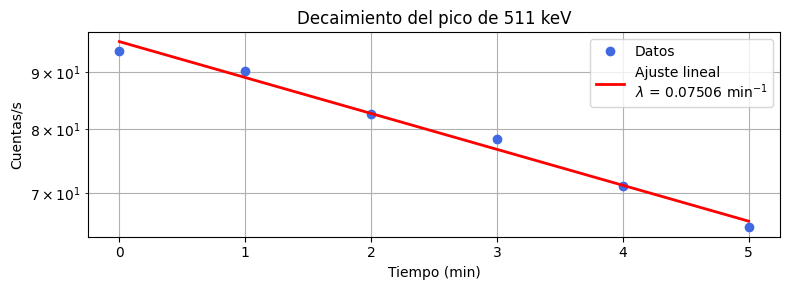

N0 = 96.00
λ = 0.075061 min^-1
 Tiempo de Vida media = 9.23 min
R² = 0.98816


In [104]:
#EN ESCALA LOGARITMICA

# Ajuste lineal sobre el logaritmo de las cuentas
m, b = np.polyfit(tiempo_tapasup, np.log(cuentas_tapasup), 1)

lam_tapasup = -m
N0_tapasup = np.exp(b)

# Curva ajustada
t_fit_tapasup = np.linspace(tiempo_tapasup.min(), tiempo_tapasup.max(), 300)
cuentas_fit_tapasup = N0_tapasup * np.exp(-lam_tapasup * t_fit_tapasup)

# Gráfico
plt.figure(figsize=(8,3))
plt.plot(tiempo_tapasup, cuentas_tapasup, 'o', color='royalblue', label='Datos')
plt.plot(t_fit_tapasup, cuentas_fit_tapasup, 'r-', lw=2,
         label=f'Ajuste lineal\n$\\lambda$ = {lam_tapasup:.5f} min$^{{-1}}$')

plt.yscale('log')   # Escala logarítmica en el eje y

plt.xlabel('Tiempo (min)')
plt.ylabel('Cuentas/s')
plt.title('Decaimiento del pico de 511 keV')
plt.grid(True, which='both')
plt.legend()

plt.tight_layout()
plt.show()

# Valores ajustados en escala logarítmica
log_cuentas = np.log(cuentas_tapasup)
log_cuentas_fit = m * tiempo_tapasup + b

# Cálculo de R²
SS_res = np.sum((log_cuentas - log_cuentas_fit)**2)
SS_tot = np.sum((log_cuentas - np.mean(log_cuentas))**2)

R2 = 1 - SS_res / SS_tot

print(f"N0 = {N0_tapasup:.2f}")
print(f"λ = {lam_tapasup:.6f} min^-1")

# Vida media y tiempo de vida medio
T12 = np.log(2) / lam_tapasup

print(f" Tiempo de Vida media = {T12:.2f} min")
print(f"R² = {R2:.5f}")

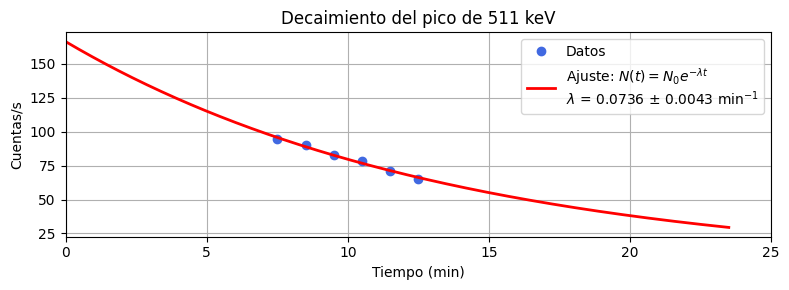

N0 = 166.27 ± 6.92
λ = 0.073650 ± 0.004280 min^-1
Vida media = 9.41 ± 0.55 min


In [105]:
# Tiempo real (la primera medición ocurrió 7.5 min después del inicio)
tiempo_real = tiempo_tapasup + 7.5

# Ajuste
popt, pcov = curve_fit(exponencial, tiempo_real, cuentas_tapasup,
                       p0=[cuentas_tapasup[0], 0.01])

N0_tapasup, lam_tapasup = popt
err_N0_tapasup, err_lam_tapasup = np.sqrt(np.diag(pcov))

# Curva ajustada (desde t = 0 min)
t_fit_tapasup = np.linspace(0, tiempo_tapasup.max() + 7.5 + 11, 500) #al tiempo max le sumo el tiempo en el que arranco y la duracion de la tapa inf
cuentas_fit_tapasup = exponencial(t_fit_tapasup, N0_tapasup, lam_tapasup)

# Gráfico
plt.figure(figsize=(8,3))
plt.plot(tiempo_real, cuentas_tapasup, 'o', color='royalblue', label='Datos')
plt.plot(t_fit_tapasup, cuentas_fit_tapasup, 'r-', lw=2,
         label=f'Ajuste: $N(t)=N_0e^{{-\\lambda t}}$\n'
               f'$\\lambda$ = {lam_tapasup:.4f} ± {err_lam_tapasup:.4f} min$^{{-1}}$')
plt.xlim(0, 25)
plt.xlabel('Tiempo (min)')
plt.ylabel('Cuentas/s')
plt.title('Decaimiento del pico de 511 keV')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
print(f"N0 = {N0_tapasup:.2f} ± {err_N0_tapasup:.2f}")
print(f"λ = {lam_tapasup:.6f} ± {err_lam_tapasup:.6f} min^-1")

T12_tapasup = np.log(2) / lam_tapasup
err_T12_tapasup = np.log(2) * err_lam_tapasup / lam_tapasup**2

print(f"Vida media = {T12_tapasup:.2f} ± {err_T12_tapasup:.2f} min")

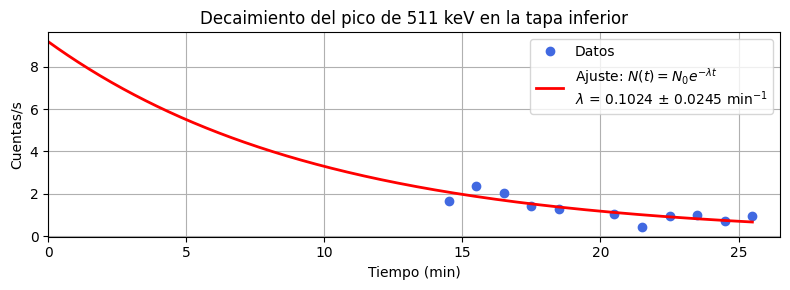

N0 = 9.18 ± 4.02
λ = 0.102358 ± 0.024454 min^-1
Vida media = 6.77 ± 1.62 min


In [106]:
# Tiempo real (la primera medición ocurrió 7.5 min después del inicio)
tiempo_real = tiempo_tapainf + 14.5

# Ajuste
popt, pcov = curve_fit(exponencial, tiempo_real, cuentas_tapainf,
                       p0=[cuentas_tapainf[0], 0.01])

N0_tapainf, lam_tapainf = popt
err_N0_tapainf, err_lam_tapainf = np.sqrt(np.diag(pcov))

# Curva ajustada (desde t = -7.5 min hasta 11 min después del último dato)
t_fit_tapainf = np.linspace(0, tiempo_real.max(), 500)
cuentas_fit_tapainf = exponencial(t_fit_tapainf, N0_tapainf, lam_tapainf)

# Gráfico
plt.figure(figsize=(8,3))
plt.plot(tiempo_real, cuentas_tapainf, 'o', color='royalblue', label='Datos')
plt.plot(t_fit_tapainf, cuentas_fit_tapainf, 'r-', lw=2,
         label=f'Ajuste: $N(t)=N_0e^{{-\\lambda t}}$\n'
               f'$\\lambda$ = {lam_tapainf:.4f} ± {err_lam_tapainf:.4f} min$^{{-1}}$')

plt.xlim(0, tiempo_real.max()+1)

plt.xlabel('Tiempo (min)')
plt.ylabel('Cuentas/s')
plt.title('Decaimiento del pico de 511 keV en la tapa inferior')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"N0 = {N0_tapainf:.2f} ± {err_N0_tapainf:.2f}")
print(f"λ = {lam_tapainf:.6f} ± {err_lam_tapainf:.6f} min^-1")

T12_tapainf = np.log(2) / lam_tapainf
err_T12_tapainf = np.log(2) * err_lam_tapainf / lam_tapainf**2

print(f"Vida media = {T12_tapainf:.2f} ± {err_T12_tapainf:.2f} min")

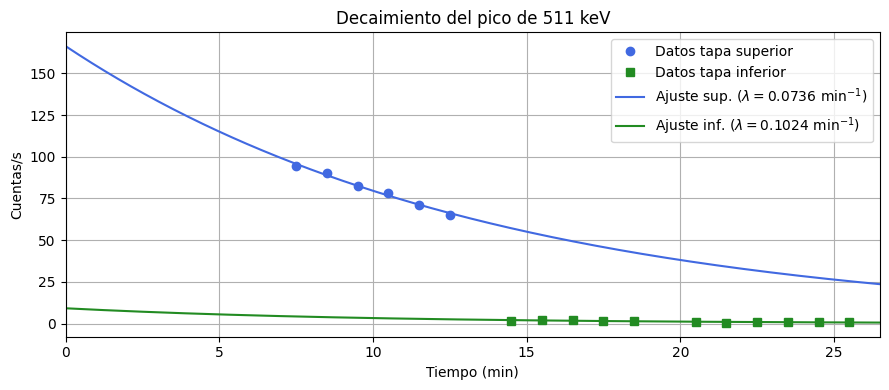

Tapa superior
N0 = 166.27 ± 6.92
λ = 0.073650 ± 0.004280 min^-1
Vida media = 9.41 min

Tapa inferior
N0 = 9.18 ± 4.02
λ = 0.102358 ± 0.024454 min^-1
Vida media = 6.77 min


In [107]:
# Tiempos reales
tiempo_real_sup = tiempo_tapasup + 7.5
tiempo_real_inf = tiempo_tapainf + 14.5

# Ajuste tapa superior
popt_sup, pcov_sup = curve_fit(exponencial, tiempo_real_sup, cuentas_tapasup,
                               p0=[cuentas_tapasup[0], 0.01])

N0_sup, lam_sup = popt_sup
err_N0_sup, err_lam_sup = np.sqrt(np.diag(pcov_sup))

# Ajuste tapa inferior
popt_inf, pcov_inf = curve_fit(exponencial, tiempo_real_inf, cuentas_tapainf,
                               p0=[cuentas_tapainf[0], 0.01])

N0_inf, lam_inf = popt_inf
err_N0_inf, err_lam_inf = np.sqrt(np.diag(pcov_inf))

# Curvas ajustadas
t_fit_sup = np.linspace(0, tiempo_real_inf.max() + 1, 500)
cuentas_fit_sup = exponencial(t_fit_sup, N0_sup, lam_sup)

t_fit_inf = np.linspace(0, tiempo_real_inf.max() + 1, 500)
cuentas_fit_inf = exponencial(t_fit_inf, N0_inf, lam_inf)

# Gráfico conjunto
plt.figure(figsize=(9,4))

# Datos
plt.plot(tiempo_real_sup, cuentas_tapasup, 'o',
         color='royalblue', label='Datos tapa superior')

plt.plot(tiempo_real_inf, cuentas_tapainf, 's',
         color='forestgreen', label='Datos tapa inferior')

# Ajustes
plt.plot(t_fit_sup, cuentas_fit_sup, '-',
         color='royalblue',
         label=f'Ajuste sup. ($\\lambda={lam_sup:.4f}$ min$^{{-1}}$)')

plt.plot(t_fit_inf, cuentas_fit_inf, '-',
         color='forestgreen',
         label=f'Ajuste inf. ($\\lambda={lam_inf:.4f}$ min$^{{-1}}$)')

plt.xlim(0, tiempo_real_inf.max() + 1)

plt.xlabel('Tiempo (min)')
plt.ylabel('Cuentas/s')
plt.title('Decaimiento del pico de 511 keV')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Resultados
print("Tapa superior")
print(f"N0 = {N0_sup:.2f} ± {err_N0_sup:.2f}")
print(f"λ = {lam_sup:.6f} ± {err_lam_sup:.6f} min^-1")
print(f"Vida media = {np.log(2)/lam_sup:.2f} min")

print("\nTapa inferior")
print(f"N0 = {N0_inf:.2f} ± {err_N0_inf:.2f}")
print(f"λ = {lam_inf:.6f} ± {err_lam_inf:.6f} min^-1")
print(f"Vida media = {np.log(2)/lam_inf:.2f} min")

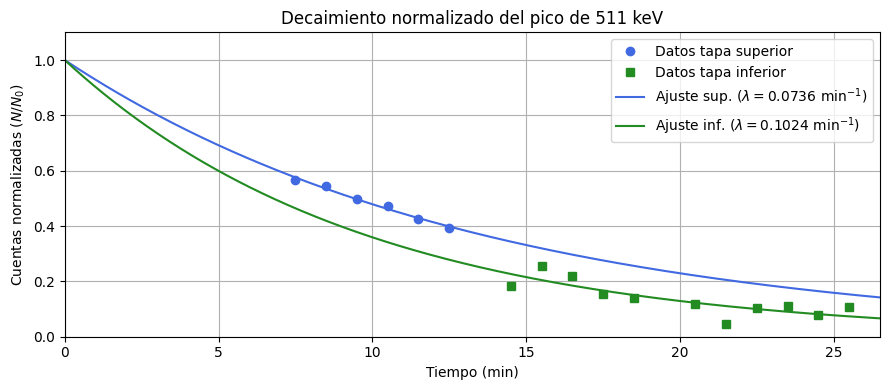

In [108]:
# -----------------------------
# Normalización por N0
# -----------------------------

# Cuentas normalizadas
cuentas_norm_sup = cuentas_tapasup / N0_sup
cuentas_norm_inf = cuentas_tapainf / N0_inf

# Curvas ajustadas normalizadas
cuentas_fit_norm_sup = cuentas_fit_sup / N0_sup
cuentas_fit_norm_inf = cuentas_fit_inf / N0_inf

# Gráfico
plt.figure(figsize=(9,4))

# Datos experimentales
plt.plot(tiempo_real_sup, cuentas_norm_sup, 'o',
         color='royalblue', label='Datos tapa superior')

plt.plot(tiempo_real_inf, cuentas_norm_inf, 's',
         color='forestgreen', label='Datos tapa inferior')

# Ajustes
plt.plot(t_fit_sup, cuentas_fit_norm_sup, '-',
         color='royalblue',
         label=f'Ajuste sup. ($\\lambda={lam_sup:.4f}$ min$^{{-1}}$)')

plt.plot(t_fit_inf, cuentas_fit_norm_inf, '-',
         color='forestgreen',
         label=f'Ajuste inf. ($\\lambda={lam_inf:.4f}$ min$^{{-1}}$)')

plt.xlim(0, max(tiempo_real_sup.max(), tiempo_real_inf.max()) + 1)
plt.ylim(0, 1.1)

plt.xlabel('Tiempo (min)')
plt.ylabel(r'Cuentas normalizadas ($N/N_0$)')
plt.title('Decaimiento normalizado del pico de 511 keV')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Incluyo los errores

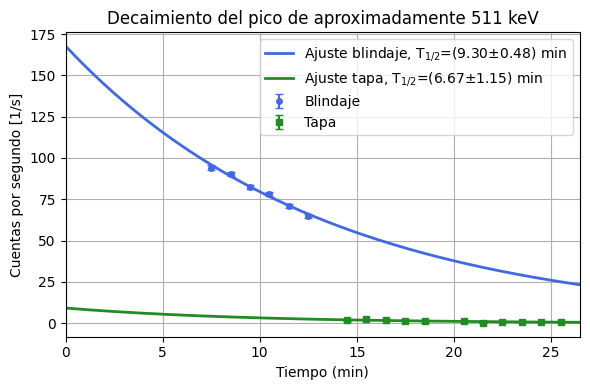

Tapa superior
N0 = 167.66 ± 6.39
λ = 0.074503 ± 0.003833 min⁻¹
Vida media = 9.30 ± 0.48 min

Tapa inferior
N0 = 9.19 ± 3.04
λ = 0.103902 ± 0.017978 min⁻¹
Vida media = 6.67 ± 1.15 min


In [119]:

# Función exponencial
def exponencial(t, N0, lam):
    return N0 * np.exp(-lam * t)

# ============================
# Tiempos reales
# ============================
tiempo_real_sup = tiempo_tapasup + 7.5
tiempo_real_inf = tiempo_tapainf + 14.5

# ============================
# Ajustes
# ============================
popt_sup, pcov_sup = curve_fit(
    exponencial,
    tiempo_real_sup,
    cuentas_tapasup,
    sigma=cuentastapasup_error,
    absolute_sigma=True,
    p0=[cuentas_tapasup[0], 0.01]
)

N0_sup, lam_sup = popt_sup
err_N0_sup, err_lam_sup = np.sqrt(np.diag(pcov_sup))

popt_inf, pcov_inf = curve_fit(
    exponencial,
    tiempo_real_inf,
    cuentas_tapainf,
    sigma=cuentastapainf_error,
    absolute_sigma=True,
    p0=[cuentas_tapainf[0], 0.01]
)

N0_inf, lam_inf = popt_inf
err_N0_inf, err_lam_inf = np.sqrt(np.diag(pcov_inf))

# ============================
# Curvas ajustadas
# ============================
t_fit = np.linspace(0, tiempo_real_inf.max() + 1, 500)

ajuste_sup = exponencial(t_fit, N0_sup, lam_sup)
ajuste_inf = exponencial(t_fit, N0_inf, lam_inf)

# ============================
# Vidas medias
# ============================
T12_sup = np.log(2) / lam_sup
err_T12_sup = np.log(2) * err_lam_sup / lam_sup**2

T12_inf = np.log(2) / lam_inf
err_T12_inf = np.log(2) * err_lam_inf / lam_inf**2

# ============================
# Gráfico
# ============================
plt.figure(figsize=(6,4))

plt.errorbar(
    tiempo_real_sup,
    cuentas_tapasup,
    yerr=cuentastapasup_error,
    fmt='o',
    color='royalblue',
    capsize=3,
    markersize=4,
    label='Blindaje'
)

plt.errorbar(
    tiempo_real_inf,
    cuentas_tapainf,
    yerr=cuentastapainf_error,
    fmt='s',
    color='forestgreen',
    capsize=3,
    markersize=4,
    label='Tapa'
)

plt.plot(
    t_fit,
    ajuste_sup,
    color='royalblue',
    linewidth=2,
    label=f'Ajuste blindaje, T$_{{1/2}}$=({T12_sup:.2f}±{err_T12_sup:.2f}) min'
)

plt.plot(
    t_fit,
    ajuste_inf,
    color='forestgreen',
    linewidth=2,
    label=f'Ajuste tapa, T$_{{1/2}}$=({T12_inf:.2f}±{err_T12_inf:.2f}) min'
)

plt.xlim(0, tiempo_real_inf.max() + 1)

plt.xlabel('Tiempo (min)')
plt.ylabel('Cuentas por segundo [1/s]')
plt.title('Decaimiento del pico de aproximadamente 511 keV')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# ============================
# Resultados
# ============================

print("Tapa superior")
print(f"N0 = {N0_sup:.2f} ± {err_N0_sup:.2f}")
print(f"λ = {lam_sup:.6f} ± {err_lam_sup:.6f} min⁻¹")
print(f"Vida media = {T12_sup:.2f} ± {err_T12_sup:.2f} min")

print("\nTapa inferior")
print(f"N0 = {N0_inf:.2f} ± {err_N0_inf:.2f}")
print(f"λ = {lam_inf:.6f} ± {err_lam_inf:.6f} min⁻¹")
print(f"Vida media = {T12_inf:.2f} ± {err_T12_inf:.2f} min")

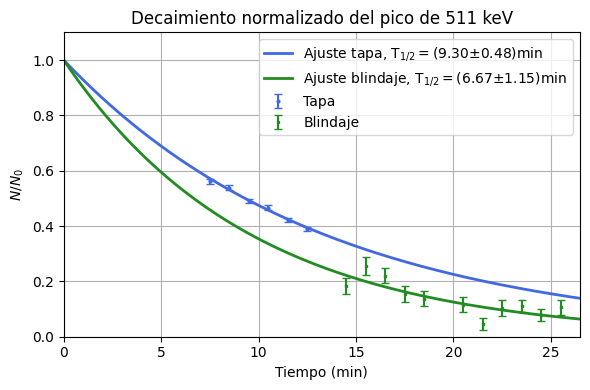

Tapa superior
N0 = 167.66 ± 6.39
λ = 0.074503 ± 0.003833 min⁻¹
Vida media = 9.30 ± 0.48 min

Tapa inferior
N0 = 9.19 ± 3.04
λ = 0.103902 ± 0.017978 min⁻¹
Vida media = 6.67 ± 1.15 min


In [110]:
# Función exponencial
def exponencial(t, N0, lam):
    return N0 * np.exp(-lam * t)

# ============================
# Tiempos reales
# ============================
tiempo_real_sup = tiempo_tapasup + 7.5
tiempo_real_inf = tiempo_tapainf + 14.5

# ============================
# Ajustes
# ============================
popt_sup, pcov_sup = curve_fit(
    exponencial,
    tiempo_real_sup,
    cuentas_tapasup,
    sigma=cuentastapasup_error,
    absolute_sigma=True,
    p0=[cuentas_tapasup[0], 0.01]
)

N0_sup, lam_sup = popt_sup
err_N0_sup, err_lam_sup = np.sqrt(np.diag(pcov_sup))

popt_inf, pcov_inf = curve_fit(
    exponencial,
    tiempo_real_inf,
    cuentas_tapainf,
    sigma=cuentastapainf_error,
    absolute_sigma=True,
    p0=[cuentas_tapainf[0], 0.01]
)

N0_inf, lam_inf = popt_inf
err_N0_inf, err_lam_inf = np.sqrt(np.diag(pcov_inf))

# ============================
# Normalización
# ============================

cuentas_norm_sup = cuentas_tapasup / N0_sup
cuentas_norm_inf = cuentas_tapainf / N0_inf

errores_norm_sup = cuentastapasup_error / N0_sup
errores_norm_inf = cuentastapainf_error / N0_inf

# Curvas ajustadas normalizadas
t_fit = np.linspace(0, tiempo_real_inf.max() + 1, 500)

ajuste_norm_sup = np.exp(-lam_sup * t_fit)
ajuste_norm_inf = np.exp(-lam_inf * t_fit)


T12_sup = np.log(2)/lam_sup
err_T12_sup = np.log(2)*err_lam_sup/lam_sup**2

T12_inf = np.log(2)/lam_inf
err_T12_inf = np.log(2)*err_lam_inf/lam_inf**2

# ============================
# Gráfico
# ============================

plt.figure(figsize=(6,4))

plt.plot(
    t_fit,
    ajuste_norm_sup,
    color='royalblue',
    linewidth=2,
    label=f'Ajuste tapa, T$_{{1/2}}=({T12_sup:.2f} ± {err_T12_sup:.2f})$min'
)

plt.plot(
    t_fit,
    ajuste_norm_inf,
    color='forestgreen',
    linewidth=2,
    label=f'Ajuste blindaje, T$_{{1/2}}=({T12_inf:.2f}± {err_T12_inf:.2f})$min'
)

plt.errorbar(
    tiempo_real_sup,
    cuentas_norm_sup,
    yerr=errores_norm_sup,
    fmt='o',
    color='royalblue',
    capsize=3,
    markersize=2,
    label='Tapa'
)

plt.errorbar(
    tiempo_real_inf,
    cuentas_norm_inf,
    yerr=errores_norm_inf,
    fmt='s',
    color='forestgreen',
    capsize=3,
    markersize=2,
    label='Blindaje'
)
plt.xlim(0, tiempo_real_inf.max()+1)
plt.ylim(0,1.1)

plt.xlabel('Tiempo (min)')
plt.ylabel(r'$N/N_0$')
plt.title('Decaimiento normalizado del pico de 511 keV')
plt.grid(True)
plt.legend()


plt.tight_layout()
plt.show()

# ============================
# Resultados
# ============================

print("Tapa superior")
print(f"N0 = {N0_sup:.2f} ± {err_N0_sup:.2f}")
print(f"λ = {lam_sup:.6f} ± {err_lam_sup:.6f} min⁻¹")
print(f"Vida media = {T12_sup:.2f} ± {err_T12_sup:.2f} min")

print("\nTapa inferior")
print(f"N0 = {N0_inf:.2f} ± {err_N0_inf:.2f}")
print(f"λ = {lam_inf:.6f} ± {err_lam_inf:.6f} min⁻¹")
print(f"Vida media = {T12_inf:.2f} ± {err_T12_inf:.2f} min")

In [111]:
def leer_spe(nombre_archivo):
    """
    Lee un archivo .Spe de ORTEC/Maestro.

    Devuelve:
        energia      : energía (keV)
        cuentas      : cuentas por canal
        canales      : número de canal
        live_time    : tiempo vivo (s)
        real_time    : tiempo real (s)
    """

    with open(nombre_archivo, "r") as f:
        lineas = [l.strip() for l in f]

    #==============================
    # Buscar bloque de datos
    #==============================
    idx_data = lineas.index("$DATA:")

    canal_inicial, canal_final = map(int, lineas[idx_data+1].split())

    n_canales = canal_final - canal_inicial + 1

    cuentas = np.array([
        float(lineas[idx_data+2+i])
        for i in range(n_canales)
    ])

    canales = np.arange(canal_inicial, canal_final+1)

    #==============================
    # Tiempo de adquisición
    #==============================
    live_time = None
    real_time = None

    if "$MEAS_TIM:" in lineas:
        idx = lineas.index("$MEAS_TIM:")
        real_time, live_time = map(float, lineas[idx+1].split())

    #==============================
    # Calibración
    #==============================
    if "$MCA_CAL:" in lineas:

        idx = lineas.index("$MCA_CAL:")

        # cantidad de coeficientes
        ncoef = int(lineas[idx+1])

        coef = lineas[idx+2].split()

        offset = float(coef[0])
        pendiente = float(coef[1])

    elif "$ENER_FIT:" in lineas:

        idx = lineas.index("$ENER_FIT:")

        offset, pendiente = map(float, lineas[idx+1].split())

    else:
        offset = 0
        pendiente = 1

    energia = offset + pendiente*canales

    return energia, cuentas, canales, live_time, real_time

Número de canales : 8192
Live time         : 60.00 s
Real time         : 60.00 s
Calibración:
Primer canal = 1.539 keV
Último canal = 1711.451 keV


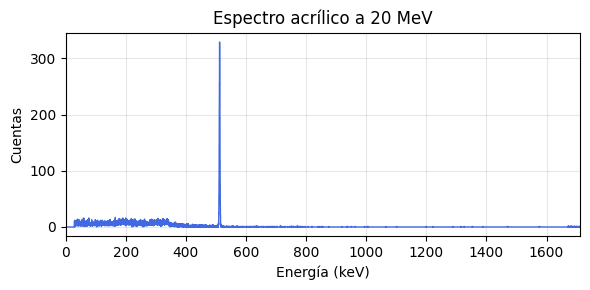

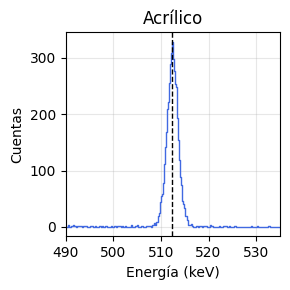

In [112]:

#==========================================================
# Leer archivo
#==========================================================

archivo = r"C:\Users\basil\OneDrive\Desktop\Lucia y Arianna formato ascii\Ac_20_MeV 000.Spe"

energia, cuentas, canales, live, real = leer_spe(archivo)

print(f"Número de canales : {len(canales)}")
print(f"Live time         : {live:.2f} s")
print(f"Real time         : {real:.2f} s")

print(f"Calibración:")
print(f"Primer canal = {energia[0]:.3f} keV")
print(f"Último canal = {energia[-1]:.3f} keV")

#==========================================================
# Gráfico
#==========================================================

plt.figure(figsize=(6,3))

plt.step(
    energia,
    cuentas,
    where="mid",
    color="royalblue",
    linewidth=1
)

plt.xlabel("Energía (keV)")
plt.ylabel("Cuentas")
plt.xlim(0, np.max(energia))
plt.title("Espectro acrílico a 20 MeV")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#==========================================================
# Gráfico zoomeado
#==========================================================
# Buscar el máximo entre 400 y 600 keV
mascara = (energia >= 400) & (energia <= 600)

indice_max = np.argmax(cuentas[mascara])

energia_max = energia[mascara][indice_max]
cuentas_max = cuentas[mascara][indice_max]

plt.figure(figsize=(3,3))

plt.step(
    energia,
    cuentas,
    where="mid",
    color="royalblue",
    linewidth=1
)

plt.xlabel("Energía (keV)")
plt.ylabel("Cuentas")
plt.xlim(490, 535)
plt.axvline(energia_max, color='black', linestyle='--', linewidth=1)


plt.title("Acrílico")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Número de canales : 8192
Live time         : 60.00 s
Real time         : 60.00 s
Calibración:
Primer canal = 1.539 keV
Último canal = 1711.451 keV


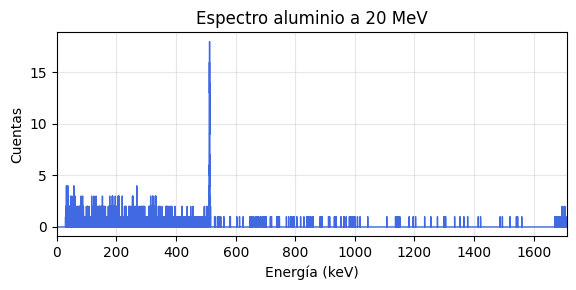

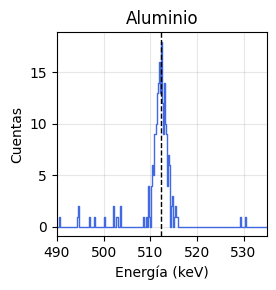

In [113]:

#==========================================================
# Leer archivo
#==========================================================

archivo = r"C:\Users\basil\OneDrive\Desktop\Lucia y Arianna formato ascii\Al_20_MeV 000.Spe"

energia, cuentas, canales, live, real = leer_spe(archivo)

print(f"Número de canales : {len(canales)}")
print(f"Live time         : {live:.2f} s")
print(f"Real time         : {real:.2f} s")

print(f"Calibración:")
print(f"Primer canal = {energia[0]:.3f} keV")
print(f"Último canal = {energia[-1]:.3f} keV")

#==========================================================
# Gráfico
#==========================================================

plt.figure(figsize=(6,3))

plt.step(
    energia,
    cuentas,
    where="mid",
    color="royalblue",
    linewidth=1
)

plt.xlabel("Energía (keV)")
plt.ylabel("Cuentas")
plt.xlim(0, np.max(energia))
plt.title("Espectro aluminio a 20 MeV")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#==========================================================
# Gráfico zoomeado
#==========================================================
# Buscar el máximo entre 400 y 600 keV
mascara = (energia >= 400) & (energia <= 600)

indice_max = np.argmax(cuentas[mascara])

energia_max = energia[mascara][indice_max]
cuentas_max = cuentas[mascara][indice_max]

plt.figure(figsize=(3,3))

plt.step(
    energia,
    cuentas,
    where="mid",
    color="royalblue",
    linewidth=1
)

plt.xlabel("Energía (keV)")
plt.ylabel("Cuentas")
plt.xlim(490, 535)
plt.axvline(energia_max, color='black', linestyle='--', linewidth=1)

plt.title("Aluminio")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Número de canales : 8192
Live time         : 61.00 s
Real time         : 60.00 s
Calibración:
Primer canal = 1.539 keV
Último canal = 1711.451 keV


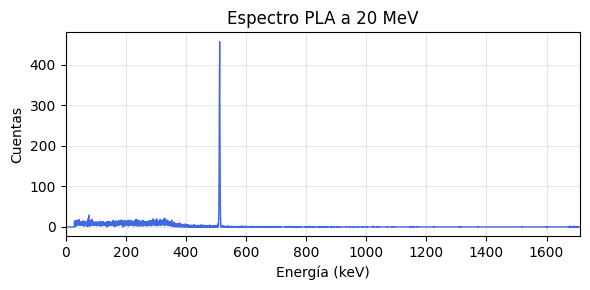

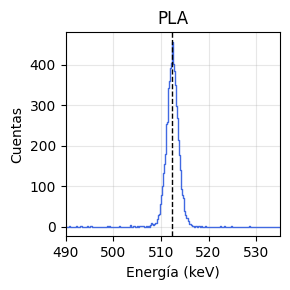

In [114]:

#==========================================================
# Leer archivo
#==========================================================

archivo = r"C:\Users\basil\OneDrive\Desktop\Lucia y Arianna formato ascii\tapa_20_MeV 000.Spe"

energia, cuentas, canales, live, real = leer_spe(archivo)

print(f"Número de canales : {len(canales)}")
print(f"Live time         : {live:.2f} s")
print(f"Real time         : {real:.2f} s")

print(f"Calibración:")
print(f"Primer canal = {energia[0]:.3f} keV")
print(f"Último canal = {energia[-1]:.3f} keV")

#==========================================================
# Gráfico
#==========================================================

plt.figure(figsize=(6,3))

plt.step(
    energia,
    cuentas,
    where="mid",
    color="royalblue",
    linewidth=1
)

plt.xlabel("Energía (keV)")
plt.ylabel("Cuentas")
plt.xlim(0, np.max(energia))
plt.title("Espectro PLA a 20 MeV")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#==========================================================
# Gráfico zoomeado
#==========================================================
# Buscar el máximo entre 400 y 600 keV
mascara = (energia >= 400) & (energia <= 600)

indice_max = np.argmax(cuentas[mascara])

energia_max = energia[mascara][indice_max]
cuentas_max = cuentas[mascara][indice_max]

plt.figure(figsize=(3,3))

plt.step(
    energia,
    cuentas,
    where="mid",
    color="royalblue",
    linewidth=1
)

plt.xlabel("Energía (keV)")
plt.ylabel("Cuentas")
plt.xlim(490, 535)
plt.axvline(energia_max, color='black', linestyle='--', linewidth=1)

plt.title("PLA")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

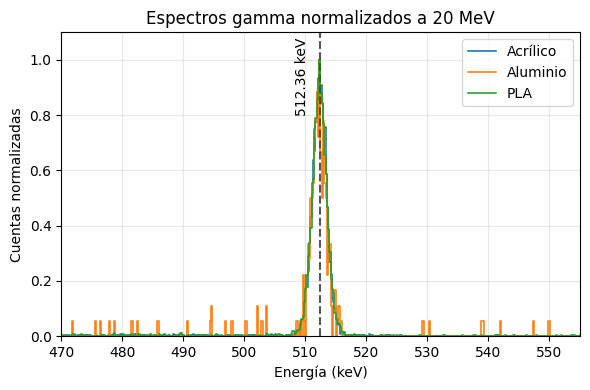

In [115]:
#==========================================================
# Archivos
#==========================================================

archivos = {
    "Acrílico": r"C:\Users\basil\OneDrive\Desktop\Lucia y Arianna formato ascii\Ac_20_MeV 000.Spe",
    "Aluminio": r"C:\Users\basil\OneDrive\Desktop\Lucia y Arianna formato ascii\Al_20_MeV 000.Spe",
    "PLA": r"C:\Users\basil\OneDrive\Desktop\Lucia y Arianna formato ascii\tapa_20_MeV 000.Spe"
}

plt.figure(figsize=(6,4))

for nombre, archivo in archivos.items():

    energia, cuentas, canales, live, real = leer_spe(archivo)

    # Buscar el máximo entre 400 y 600 keV
    mascara = (energia >= 400) & (energia <= 600)

    cuentas_norm = cuentas / np.max(cuentas[mascara])

    plt.step(
        energia,
        cuentas_norm,
        where="mid",
        linewidth=1.2,
        label=nombre
    )

    # Energía del máximo
    indice_max = np.argmax(cuentas[mascara])
    energia_max = energia[mascara][indice_max]

    plt.axvline(energia_max, color='black', linestyle='--', alpha=0.3)
    
    
plt.xlim(470,555)
plt.ylim(0,1.1)
plt.text(energia_max - 4, 1.08,f'{energia_max:.2f} keV', color='black', rotation=90, va='top')
plt.xlabel("Energía (keV)")
plt.ylabel("Cuentas normalizadas")
plt.title("Espectros gamma normalizados a 20 MeV")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

